In [1]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from IPython.display import Image, display
import os

load_dotenv()
API_KEY = os.getenv("SILICON_API_KEY")
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key=API_KEY,
    temperature=0.0
)


def display_graph(app):
    # 使用 Graphviz 渲染（Colab 最稳定的方案）
    try:
        display(Image(app.get_graph(xray=True).draw_png()))
    except Exception as e:
        print(f"Graphviz 渲染失败: {e}")
        print("\n使用 Mermaid 文本方式显示:")
        print(app.get_graph(xray=True).draw_mermaid())

🤔 思考中... (迭代 0 + 1)
⚡ 执行工具...
🤔 思考中... (迭代 1 + 1)
⚡ 执行工具...
🤔 思考中... (迭代 2 + 1)
⚡ 执行工具...
🤔 思考中... (迭代 3 + 1)
⚡ 执行工具...
🤔 思考中... (迭代 4 + 1)


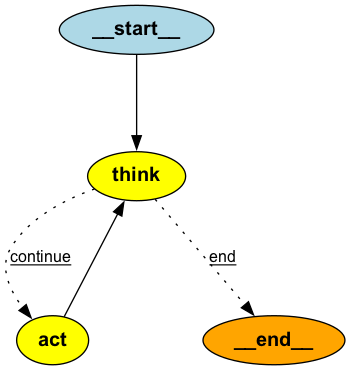

In [2]:
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langchain_core.messages import HumanMessage
from typing import Annotated, TypedDict, Literal
from langgraph.graph.message import add_messages


class AgentLoopState(TypedDict):
    messages: Annotated[list, add_messages]
    iterations: int
    max_iterations: int
    final_answer: str


def should_continue(state: AgentLoopState) -> Literal["continue", "end"]:
    """决定是否继续循环"""
    # 检查是否有最终答案
    if state.get("final_answer"):
        return "end"

    # 检查是否超过最大迭代次数
    if state["iterations"] >= state["max_iterations"]:
        return "end"

    return "continue"


def think_node(state: AgentLoopState) -> dict:
    """思考节点"""
    print(f"🤔 思考中... (迭代 {state['iterations']} + 1)")

    # LLM 推理
    messages = state["messages"]
    response = model.invoke(messages)

    # 检查是否有答案
    if "最终答案：" in response.content:
        return {
            "final_answer": response.content,
            "iterations": state["iterations"] + 1
        }

    return {
        "messages": [response],
        "iterations": state["iterations"] + 1
    }


def act_node(state: AgentLoopState) -> dict:
    """行动节点（执行工具）"""
    print("⚡ 执行工具...")

    # 执行工具，获取结果
    tool_result = "工具执行结果..."
    return {
        "messages": [HumanMessage(content=f"观察：{tool_result}")]
    }


# 构建循环图
loop_graph = StateGraph(AgentLoopState)
loop_graph.add_node("think", think_node)
loop_graph.add_node("act", act_node)

loop_graph.add_edge(START, "think")
loop_graph.add_conditional_edges(
    "think",
    should_continue,
    {
        "continue": "act",
        "end": END
    }
)
loop_graph.add_edge("act", "think")  # 形成循环

loop_app = loop_graph.compile()

# 运行
result = loop_app.invoke({
    "messages": [HumanMessage(content="帮我查询北京今天的天气")],
    "iterations": 0,
    "max_iterations": 5,
    "final_answer": ""
})

display_graph(loop_app)